In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import time

print("Benchmarking Data Manipulation (50 cols x 50,000 rows)...")
start_time = time.time()

# 1. Generate the dataset
df = pd.DataFrame(np.random.rand(50000, 50), columns=[f'col_{i}' for i in range(50)])

# 2. Perform heavy operations: rolling mean, standard deviation, and sorting
df_rolling = df.rolling(window=100).mean()
df_sum = df_rolling.sum(axis=1)
df_sorted = df.sort_values(by='col_25')

end_time = time.time()
print(f"Data operations completed in {end_time - start_time:.4f} seconds.")

Benchmarking Data Manipulation (50 cols x 50,000 rows)...
Data operations completed in 0.1183 seconds.


In [4]:
import numpy as np
import time

print("Benchmarking Matrix Multiplication (5000 x 5000)...")
start_time = time.time()

# Create two massive matrices
matrix_a = np.random.rand(5000, 5000)
matrix_b = np.random.rand(5000, 5000)

# Multiply them together (highly CPU intensive)
result = np.dot(matrix_a, matrix_b)

end_time = time.time()
print(f"Matrix multiplication completed in {end_time - start_time:.4f} seconds.")

Benchmarking Matrix Multiplication (5000 x 5000)...
Matrix multiplication completed in 1.8952 seconds.


In [5]:
import time

def find_primes(limit):
    primes = []
    for num in range(2, limit + 1):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return len(primes)

print("Benchmarking Single-Core CPU (Primes up to 2,000,000)...")
start_time = time.time()

prime_count = find_primes(2000000)

end_time = time.time()
print(f"Found {prime_count} primes in {end_time - start_time:.4f} seconds.")

Benchmarking Single-Core CPU (Primes up to 2,000,000)...
Found 148933 primes in 7.7277 seconds.


In [6]:
import os
import multiprocessing

# 1. Detect the total number of logical cores on your laptop
total_cores = str(multiprocessing.cpu_count())

# 2. Force all standard math backends to use these cores
# CRITICAL: This must be done BEFORE importing numpy
os.environ["OMP_NUM_THREADS"] = total_cores
os.environ["OPENBLAS_NUM_THREADS"] = total_cores
os.environ["MKL_NUM_THREADS"] = total_cores
os.environ["VECLIB_MAXIMUM_THREADS"] = total_cores
os.environ["NUMEXPR_NUM_THREADS"] = total_cores

import numpy as np
import time

print(f"System detected {total_cores} logical CPU cores.")
print("Benchmarking Matrix Multiplication (5000 x 5000)...")

# 3. Create the matrices
start_time = time.time()
matrix_a = np.random.rand(5000, 5000)
matrix_b = np.random.rand(5000, 5000)

# 4. Perform the calculation
result = np.dot(matrix_a, matrix_b)

end_time = time.time()
print(f"Matrix multiplication completed in {end_time - start_time:.4f} seconds.")

System detected 16 logical CPU cores.
Benchmarking Matrix Multiplication (5000 x 5000)...
Matrix multiplication completed in 1.8911 seconds.


In [7]:
import os

data_dir = "C:/Users/anils/OneDrive/Documents/Foundation Project/projectData/P3_Face_verification/faces"

people = os.listdir(data_dir)
print("Number of people (folders):", len(people))

# Count images per person
image_counts = {}
for person in people:
    person_path = os.path.join(data_dir, person)
    if os.path.isdir(person_path):
        images = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        image_counts[person] = len(images)

print("Total images:", sum(image_counts.values()))
print("People with only 1 image:", sum(1 for c in image_counts.values() if c == 1))
print("People with 2+ images:", sum(1 for c in image_counts.values() if c >= 2))

# Distribution of image counts
import pandas as pd
counts_series = pd.Series(image_counts)
print(counts_series.describe())
print(counts_series.value_counts().sort_index())

Number of people (folders): 1322
Total images: 7233
People with only 1 image: 0
People with 2+ images: 1322
count    1322.000000
mean        5.471256
std        17.631165
min         2.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       530.000000
dtype: float64
2      626
3      232
4      145
5       88
6       36
7       30
8       24
9       19
10      10
11      12
12       9
13       9
14       8
15      10
16       1
17       5
18       4
19       6
20       5
21       4
22       5
23       1
24       2
26       1
28       2
29       2
30       1
31       2
32       1
33       1
35       1
36       1
37       1
39       2
41       2
42       2
44       1
48       1
52       1
53       1
55       1
60       1
71       1
77       1
109      1
121      1
236      1
530      1
Name: count, dtype: int64


In [8]:
import random
import os
from itertools import combinations

random.seed(42)
max_pairs_per_person = 3

matching_pairs = []
pairs_per_person_log = {}

for person, count in image_counts.items():
    person_path = os.path.join(data_dir, person)
    images = [os.path.join(person_path, f) for f in os.listdir(person_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    all_combos = list(combinations(images, 2))
    random.shuffle(all_combos)
    selected = all_combos[:max_pairs_per_person]

    for img1, img2 in selected:
        matching_pairs.append((img1, img2, 1))

    pairs_per_person_log[person] = len(selected)

print("Total matching pairs generated:", len(matching_pairs))
print("People contributing exactly 1 pair (only 2 images):",
      sum(1 for v in pairs_per_person_log.values() if v == 1))
print("People contributing the full capped 3 pairs:",
      sum(1 for v in pairs_per_person_log.values() if v == max_pairs_per_person))

Total matching pairs generated: 2714
People contributing exactly 1 pair (only 2 images): 626
People contributing the full capped 3 pairs: 696


Step 2: Generate an equal number of mismatching pairs, so the dataset stays balanced:

In [9]:
all_people = list(image_counts.keys())
target_count = len(matching_pairs)  # 2,714 - match this exactly

mismatching_pairs = []
seen_pairs = set()

while len(mismatching_pairs) < target_count:
    p1, p2 = random.sample(all_people, 2)  # two different people

    img1 = random.choice(os.listdir(os.path.join(data_dir, p1)))
    img2 = random.choice(os.listdir(os.path.join(data_dir, p2)))

    combo_key = (p1, img1, p2, img2)
    if combo_key in seen_pairs:
        continue
    seen_pairs.add(combo_key)

    img1_path = os.path.join(data_dir, p1, img1)
    img2_path = os.path.join(data_dir, p2, img2)
    mismatching_pairs.append((img1_path, img2_path, 0))

print("Total mismatching pairs generated:", len(mismatching_pairs))

# Combine and shuffle into one pairs dataset
all_pairs = matching_pairs + mismatching_pairs
random.shuffle(all_pairs)
print("Total pairs dataset size:", len(all_pairs))
print("Label balance check:", sum(1 for p in all_pairs if p[2]==1), "matching /",
      sum(1 for p in all_pairs if p[2]==0), "mismatching")

Total mismatching pairs generated: 2714
Total pairs dataset size: 5428
Label balance check: 2714 matching / 2714 mismatching


Step 3: Train/validation split

In [10]:
from sklearn.model_selection import train_test_split

# Split at the pair level - stratify keeps the 50/50 label balance in both splits
train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=0.15,        # 15% held out for validation
    stratify=[p[2] for p in all_pairs],
    random_state=42
)

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))
print("Train label balance:", sum(1 for p in train_pairs if p[2]==1), "match /",
      sum(1 for p in train_pairs if p[2]==0), "mismatch")
print("Val label balance:", sum(1 for p in val_pairs if p[2]==1), "match /",
      sum(1 for p in val_pairs if p[2]==0), "mismatch")

Train pairs: 4613
Val pairs: 815
Train label balance: 2307 match / 2306 mismatch
Val label balance: 407 match / 408 mismatch


Siamese network - Step 4 -- Koch et al. paper (twin CNN encoders → L1 distance → sigmoid probability of match):  https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf

In [11]:
import torch 
!pip install torchvision

In [12]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

torch: 2.4.1+cpu
torchvision: 0.19.1+cpu
CUDA available: False


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

torch.set_num_threads(8)  # use all 8 physical cores for CPU math

IMG_SIZE = 100

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class PairsDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path1, path2, label = self.pairs[idx]
        img1 = self.transform(Image.open(path1).convert('RGB'))
        img2 = self.transform(Image.open(path2).convert('RGB'))
        return img1, img2, torch.tensor(label, dtype=torch.float32)

train_dataset = PairsDataset(train_pairs, train_transform)
val_dataset = PairsDataset(val_pairs, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 289
Val batches: 51


Building siamese network

In [14]:
import torch.nn as nn

class BaseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            flat_size = self.conv(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_network = BaseNetwork()
        self.out = nn.Linear(256, 1)

    def forward(self, img1, img2):
        feat1 = self.base_network(img1)
        feat2 = self.base_network(img2)
        l1_dist = torch.abs(feat1 - feat2)
        prediction = torch.sigmoid(self.out(l1_dist))
        return prediction.squeeze(1)

device = torch.device("cpu")
model = SiameseNetwork().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)

SiameseNetwork(
  (base_network): BaseNetwork(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Sequential(
      (0): Linear(in_features=10368, out_features=256, bias=True)
      (1): Sigmoid()
    )
  )
  (out): Linear(in_features=256, out_features=1, bias=True)
)
Total trainable parameters: 2784577


Step 4c: Time-check on 10 batches before committing to a full run:

In [15]:
import time

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

start = time.time()
for i, (img1, img2, label) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(img1, img2)
    loss = criterion(output, label)
    loss.backward()
    optimizer.step()
    if i == 9:
        break
elapsed = time.time() - start

batches_per_epoch = len(train_loader)
est_epoch_time = (elapsed / 10) * batches_per_epoch
print(f"10 batches took {elapsed:.1f}s -> estimated {est_epoch_time/60:.1f} min per epoch")
print(f"Estimated total for 15 epochs: {est_epoch_time*15/60:.1f} min")

10 batches took 3.0s -> estimated 1.5 min per epoch
Estimated total for 15 epochs: 21.9 min


Step 5: Train the network, with validation tracked each epoch so we can watch for overfitting:

In [16]:
import time

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, label in loader:
            output = model(img1, img2)
            loss = criterion(output, label)
            total_loss += loss.item() * label.size(0)
            preds = (output > 0.5).float()
            correct += (preds == label).sum().item()
            total += label.size(0)
    return total_loss / total, correct / total

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

EPOCHS = 15
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    epoch_start = time.time()

    for img1, img2, label in train_loader:
        optimizer.zero_grad()
        output = model(img1, img2)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * label.size(0)
        preds = (output > 0.5).float()
        correct += (preds == label).sum().item()
        total += label.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_time:.0f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    # Save the best model so far (by validation loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_siamese_model.pt')
        print(f"  -> New best model saved (val_loss: {val_loss:.4f})")

Epoch 1/15 (90s) - train_loss: 0.6918, train_acc: 0.4986 - val_loss: 0.6820, val_acc: 0.5325
  -> New best model saved (val_loss: 0.6820)
Epoch 2/15 (106s) - train_loss: 0.6786, train_acc: 0.5558 - val_loss: 0.6475, val_acc: 0.6503
  -> New best model saved (val_loss: 0.6475)
Epoch 3/15 (99s) - train_loss: 0.6571, train_acc: 0.6115 - val_loss: 0.6389, val_acc: 0.6307
  -> New best model saved (val_loss: 0.6389)
Epoch 4/15 (114s) - train_loss: 0.6434, train_acc: 0.6196 - val_loss: 0.6365, val_acc: 0.6417
  -> New best model saved (val_loss: 0.6365)
Epoch 5/15 (101s) - train_loss: 0.6353, train_acc: 0.6406 - val_loss: 0.6008, val_acc: 0.6761
  -> New best model saved (val_loss: 0.6008)
Epoch 6/15 (109s) - train_loss: 0.6222, train_acc: 0.6521 - val_loss: 0.5910, val_acc: 0.6969
  -> New best model saved (val_loss: 0.5910)
Epoch 7/15 (114s) - train_loss: 0.6167, train_acc: 0.6597 - val_loss: 0.5899, val_acc: 0.7129
  -> New best model saved (val_loss: 0.5899)
Epoch 8/15 (106s) - train_los

In [17]:
# Load the best checkpoint before continuing (safety net in case kernel state drifted)
model.load_state_dict(torch.load('best_siamese_model.pt'))
print("Loaded best checkpoint, resuming training...")

EPOCHS_MORE = 15
start_epoch = len(history['train_loss'])  # continues numbering from where we left off (15)

for epoch in range(EPOCHS_MORE):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    epoch_start = time.time()

    for img1, img2, label in train_loader:
        optimizer.zero_grad()
        output = model(img1, img2)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * label.size(0)
        preds = (output > 0.5).float()
        correct += (preds == label).sum().item()
        total += label.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start
    current_epoch = start_epoch + epoch + 1
    print(f"Epoch {current_epoch}/{start_epoch + EPOCHS_MORE} ({epoch_time:.0f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_siamese_model.pt')
        print(f"  -> New best model saved (val_loss: {val_loss:.4f})")

Loaded best checkpoint, resuming training...


C:\Users\anils\AppData\Local\Temp\ipykernel_29620\2789845635.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_siamese_model.pt'))


Epoch 16/30 (94s) - train_loss: 0.5430, train_acc: 0.7321 - val_loss: 0.5379, val_acc: 0.7301
Epoch 17/30 (91s) - train_loss: 0.5320, train_acc: 0.7401 - val_loss: 0.5340, val_acc: 0.7350
  -> New best model saved (val_loss: 0.5340)
Epoch 18/30 (89s) - train_loss: 0.5296, train_acc: 0.7370 - val_loss: 0.5214, val_acc: 0.7509
  -> New best model saved (val_loss: 0.5214)
Epoch 19/30 (84s) - train_loss: 0.5296, train_acc: 0.7334 - val_loss: 0.5209, val_acc: 0.7497
  -> New best model saved (val_loss: 0.5209)
Epoch 20/30 (83s) - train_loss: 0.5160, train_acc: 0.7483 - val_loss: 0.5119, val_acc: 0.7620
  -> New best model saved (val_loss: 0.5119)
Epoch 21/30 (80s) - train_loss: 0.5148, train_acc: 0.7514 - val_loss: 0.5252, val_acc: 0.7521
Epoch 22/30 (78s) - train_loss: 0.5082, train_acc: 0.7613 - val_loss: 0.5103, val_acc: 0.7644
  -> New best model saved (val_loss: 0.5103)
Epoch 23/30 (79s) - train_loss: 0.5055, train_acc: 0.7581 - val_loss: 0.5090, val_acc: 0.7607
  -> New best model sav

In [18]:
model.load_state_dict(torch.load('best_siamese_model.pt'))
print("Loaded best checkpoint, resuming training...")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
# If val_loss doesn't improve for 3 straight epochs, LR gets cut in half

EPOCHS_MORE = 15
start_epoch = len(history['train_loss'])  # continues from 30

for epoch in range(EPOCHS_MORE):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    epoch_start = time.time()

    for img1, img2, label in train_loader:
        optimizer.zero_grad()
        output = model(img1, img2)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * label.size(0)
        preds = (output > 0.5).float()
        correct += (preds == label).sum().item()
        total += label.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)  # check if LR should drop

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start
    current_epoch = start_epoch + epoch + 1
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {current_epoch}/{start_epoch + EPOCHS_MORE} ({epoch_time:.0f}s) - "
          f"lr: {current_lr:.6f} - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_siamese_model.pt')
        print(f"  -> New best model saved (val_loss: {val_loss:.4f})")

Loaded best checkpoint, resuming training...


C:\Users\anils\AppData\Local\Temp\ipykernel_29620\2416703369.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_siamese_model.pt'))


Epoch 31/45 (82s) - lr: 0.000100 - train_loss: 0.4584, train_acc: 0.7895 - val_loss: 0.4937, val_acc: 0.7607
Epoch 32/45 (86s) - lr: 0.000100 - train_loss: 0.4534, train_acc: 0.7899 - val_loss: 0.4894, val_acc: 0.7706
Epoch 33/45 (80s) - lr: 0.000100 - train_loss: 0.4450, train_acc: 0.8006 - val_loss: 0.4847, val_acc: 0.7693
  -> New best model saved (val_loss: 0.4847)
Epoch 34/45 (81s) - lr: 0.000100 - train_loss: 0.4409, train_acc: 0.7975 - val_loss: 0.4747, val_acc: 0.7755
  -> New best model saved (val_loss: 0.4747)
Epoch 35/45 (81s) - lr: 0.000100 - train_loss: 0.4391, train_acc: 0.8053 - val_loss: 0.4852, val_acc: 0.7644
Epoch 36/45 (235s) - lr: 0.000100 - train_loss: 0.4284, train_acc: 0.8114 - val_loss: 0.4883, val_acc: 0.7693
Epoch 37/45 (76s) - lr: 0.000100 - train_loss: 0.4172, train_acc: 0.8175 - val_loss: 0.4792, val_acc: 0.7755
Epoch 38/45 (75s) - lr: 0.000100 - train_loss: 0.4195, train_acc: 0.8136 - val_loss: 0.4733, val_acc: 0.7742
  -> New best model saved (val_loss: 

Step 6: threshold selection

In [19]:
model.load_state_dict(torch.load('best_siamese_model.pt'))
model.eval()

# Collect predicted probabilities and true labels across all validation pairs
all_probs = []
all_labels = []

with torch.no_grad():
    for img1, img2, label in val_loader:
        output = model(img1, img2)
        all_probs.extend(output.tolist())
        all_labels.extend(label.tolist())

import numpy as np
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print("Probability stats for matching pairs (label=1):")
print(f"  mean: {all_probs[all_labels==1].mean():.4f}, std: {all_probs[all_labels==1].std():.4f}")
print("Probability stats for mismatching pairs (label=0):")
print(f"  mean: {all_probs[all_labels==0].mean():.4f}, std: {all_probs[all_labels==0].std():.4f}")

C:\Users\anils\AppData\Local\Temp\ipykernel_29620\49204891.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_siamese_model.pt'))


Probability stats for matching pairs (label=1):
  mean: 0.6617, std: 0.2291
Probability stats for mismatching pairs (label=0):
  mean: 0.2631, std: 0.2662


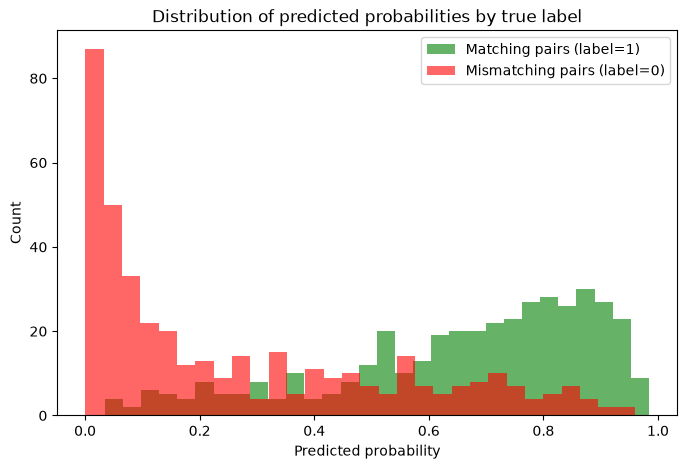

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(all_probs[all_labels==1], bins=30, alpha=0.6, label='Matching pairs (label=1)', color='green')
plt.hist(all_probs[all_labels==0], bins=30, alpha=0.6, label='Mismatching pairs (label=0)', color='red')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Distribution of predicted probabilities by true label')
plt.legend()
plt.show()

sweep candidate thresholds and compute the metrics that matter for your business case (FAR especially, given your <1% target from the mid-review deck

In [21]:
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    preds = (all_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0  # false accept rate - mismatching pairs wrongly called "match"
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0  # false reject rate - matching pairs wrongly called "no match"

    results.append({
        'threshold': round(t, 2), 'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'FAR': far, 'FRR': frr
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_acc_row = results_df.loc[results_df['accuracy'].idxmax()]
print(f"\nBest threshold by accuracy: {best_acc_row['threshold']} (accuracy={best_acc_row['accuracy']:.4f})")

 threshold  accuracy  precision   recall      FAR      FRR
      0.10  0.704294   0.630503 0.985258 0.575980 0.014742
      0.15  0.731288   0.658784 0.958231 0.495098 0.041769
      0.20  0.744785   0.676106 0.938575 0.448529 0.061425
      0.25  0.758282   0.695167 0.918919 0.401961 0.081081
      0.30  0.770552   0.714844 0.899263 0.357843 0.100737
      0.35  0.776687   0.731006 0.874693 0.321078 0.125307
      0.40  0.781595   0.748373 0.847666 0.284314 0.152334
      0.45  0.785276   0.763636 0.825553 0.254902 0.174447
      0.50  0.784049   0.781022 0.788698 0.220588 0.211302
      0.55  0.768098   0.789894 0.729730 0.193627 0.270270
      0.60  0.764417   0.817109 0.680590 0.151961 0.319410
      0.65  0.739877   0.826087 0.606880 0.127451 0.393120
      0.70  0.710429   0.832685 0.525799 0.105392 0.474201
      0.75  0.687117   0.861905 0.444717 0.071078 0.555283
      0.80  0.641718   0.866242 0.334152 0.051471 0.665848
      0.85  0.602454   0.887850 0.233415 0.029412 0.7665

Step 7a: Check for identity overlap between train and this new folder:

In [22]:
test_data_dir = r"C:\Users\anils\OneDrive\Documents\Foundation Project\projectData\P3_Face_verification\lfw-deepfunneled"

train_identities = set(image_counts.keys())  # from your original training folder
all_test_identities = set(os.listdir(test_data_dir))

overlap = train_identities & all_test_identities
held_out_identities = all_test_identities - train_identities

print("Total identities in lfw-deepfunneled:", len(all_test_identities))
print("Identities also used in training:", len(overlap))
print("Truly held-out identities (never trained on):", len(held_out_identities))

Total identities in lfw-deepfunneled: 5749
Identities also used in training: 1322
Truly held-out identities (never trained on): 4427


Step 7b: Build 500 matching + 500 mismatching pairs, only from held-out identities:

In [23]:
random.seed(123)  # different seed from training, for a clean independent sample

# Only consider held-out people who have 2+ images (needed for a matching pair)
held_out_with_images = {}
for person in held_out_identities:
    person_path = os.path.join(test_data_dir, person)
    images = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(images) >= 1:
        held_out_with_images[person] = images

people_with_2plus = [p for p, imgs in held_out_with_images.items() if len(imgs) >= 2]
print("Held-out people with 2+ images (usable for matching pairs):", len(people_with_2plus))

# --- Matching pairs ---
test_matching_pairs = []
sampled_people = random.sample(people_with_2plus, min(500, len(people_with_2plus)))
for person in sampled_people:
    imgs = held_out_with_images[person]
    img1, img2 = random.sample(imgs, 2)
    p1 = os.path.join(test_data_dir, person, img1)
    p2 = os.path.join(test_data_dir, person, img2)
    test_matching_pairs.append((p1, p2, 1))

# --- Mismatching pairs ---
all_held_out_people = list(held_out_with_images.keys())
test_mismatching_pairs = []
seen = set()
while len(test_mismatching_pairs) < len(test_matching_pairs):
    p1, p2 = random.sample(all_held_out_people, 2)
    key = tuple(sorted([p1, p2]))
    if key in seen:
        continue
    seen.add(key)
    img1 = random.choice(held_out_with_images[p1])
    img2 = random.choice(held_out_with_images[p2])
    path1 = os.path.join(test_data_dir, p1, img1)
    path2 = os.path.join(test_data_dir, p2, img2)
    test_mismatching_pairs.append((path1, path2, 0))

test_pairs = test_matching_pairs + test_mismatching_pairs
random.shuffle(test_pairs)

print("Test matching pairs:", len(test_matching_pairs))
print("Test mismatching pairs:", len(test_mismatching_pairs))
print("Total test pairs:", len(test_pairs))

Held-out people with 2+ images (usable for matching pairs): 358
Test matching pairs: 358
Test mismatching pairs: 358
Total test pairs: 716


Step 7c: Run the trained model on this true test set:

In [24]:
class PairsDataset(Dataset):  # re-use if not already in memory from earlier
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path1, path2, label = self.pairs[idx]
        img1 = self.transform(Image.open(path1).convert('RGB'))
        img2 = self.transform(Image.open(path2).convert('RGB'))
        return img1, img2, torch.tensor(label, dtype=torch.float32)

test_dataset = PairsDataset(test_pairs, val_transform)  # val_transform = no augmentation
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

model.load_state_dict(torch.load('best_siamese_model.pt', weights_only=True))
model.eval()

test_probs = []
test_labels = []

with torch.no_grad():
    for img1, img2, label in test_loader:
        output = model(img1, img2)
        test_probs.extend(output.tolist())
        test_labels.extend(label.tolist())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

print("Test set size:", len(test_probs))
print("Matching pairs mean prob:", test_probs[test_labels==1].mean().round(4))
print("Mismatching pairs mean prob:", test_probs[test_labels==0].mean().round(4))

Test set size: 716
Matching pairs mean prob: 0.6164
Mismatching pairs mean prob: 0.3187


Step 7d: Apply your locked threshold (0.45, chosen on validation — not re-tuned here) and report final metrics:

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

LOCKED_THRESHOLD = 0.45  # chosen on validation set, applied as-is to test

test_preds = (test_probs > LOCKED_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
far = fp / (fp + tn) if (fp + tn) > 0 else 0
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"FINAL TEST SET RESULTS (threshold={LOCKED_THRESHOLD})")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"FAR:       {far:.4f}")
print(f"FRR:       {frr:.4f}")
print(f"\nConfusion matrix:\nTN={tn}  FP={fp}\nFN={fn}  TP={tp}")

FINAL TEST SET RESULTS (threshold=0.45)
Accuracy:  0.7235
Precision: 0.7073
Recall:    0.7626
FAR:       0.3156
FRR:       0.2374

Confusion matrix:
TN=245  FP=113
FN=85  TP=273


In [26]:
pip install facenet-pytorch

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 13.0 MB/s  0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   -------- ------------------------------- 3.4/15.5 MB 16.7 MB/s eta 0:00:01
   -------------- ------------------------- 5.5/15.5 MB 12.9 MB/s eta 0:00:01
   ----------------------- ---------------- 9.2/15.5 MB 14.3 MB/s eta 0:00:01
   --------------------------------- ------ 12.8/15.5 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 14.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 21.5 MB/s  0:00:00
   ---------------------------------------- 0.0/198.5 MB ? eta -:--:--
    --------------------------------------- 3.1/198.5 MB 15.4 MB/s eta 0:00:13
   - -------------------------------------- 7.6/198.5 MB 18.1 MB/s eta 0:00:11
   - ---------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 10.2.0 which is incompatible.
scipy 1.18.0 requires numpy<2.8,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [28]:
from facenet_pytorch import InceptionResnetV1

# pretrained='vggface2' downloads pretrained weights automatically (one-time, ~110MB)
embedding_model = InceptionResnetV1(pretrained='vggface2').eval()

print(embedding_model)
print("Model loaded successfully")

# Quick check on one image to confirm the pipeline works end to end
import torch
from PIL import Image
from torchvision import transforms

facenet_transform = transforms.Compose([
    transforms.Resize((160, 160)),  # facenet-pytorch expects 160x160 input
    transforms.ToTensor(),
])

sample_path = test_pairs[0][0]  # reuse a path from your existing test pairs
img = facenet_transform(Image.open(sample_path).convert('RGB')).unsqueeze(0)

with torch.no_grad():
    embedding = embedding_model(img)

print("Embedding shape:", embedding.shape)  # should be [1, 512]

InceptionResnetV1(
  (conv2d_1a): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2a): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2b): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_4a): 

In [29]:
import numpy as np

embedding_model.eval()

def get_facenet_embedding(path):
    img = facenet_transform(Image.open(path).convert('RGB')).unsqueeze(0)
    with torch.no_grad():
        emb = embedding_model(img)
    return emb.squeeze(0).numpy()

def compute_pair_distances(pairs):
    distances = []
    labels = []
    for i, (path1, path2, label) in enumerate(pairs):
        emb1 = get_facenet_embedding(path1)
        emb2 = get_facenet_embedding(path2)
        dist = np.linalg.norm(emb1 - emb2)  # Euclidean distance
        distances.append(dist)
        labels.append(label)
        if (i + 1) % 100 == 0:
            print(f"Processed {i+1}/{len(pairs)} pairs...")
    return np.array(distances), np.array(labels)

print("Computing distances for validation pairs...")
val_distances, val_labels_fn = compute_pair_distances(val_pairs)

print("\nDistance stats for matching pairs (label=1):")
print(f"  mean: {val_distances[val_labels_fn==1].mean():.4f}, std: {val_distances[val_labels_fn==1].std():.4f}")
print("Distance stats for mismatching pairs (label=0):")
print(f"  mean: {val_distances[val_labels_fn==0].mean():.4f}, std: {val_distances[val_labels_fn==0].std():.4f}")

Computing distances for validation pairs...
Processed 100/815 pairs...
Processed 200/815 pairs...
Processed 300/815 pairs...
Processed 400/815 pairs...
Processed 500/815 pairs...
Processed 600/815 pairs...
Processed 700/815 pairs...
Processed 800/815 pairs...

Distance stats for matching pairs (label=1):
  mean: 0.8275, std: 0.2039
Distance stats for mismatching pairs (label=0):
  mean: 1.3842, std: 0.1178


In [30]:
from sklearn.metrics import confusion_matrix
import pandas as pd

thresholds_fn = np.arange(0.5, 1.6, 0.05)
results_fn = []

for t in thresholds_fn:
    preds = (val_distances < t).astype(int)  # BELOW threshold = match (opposite of the sigmoid model)
    tn, fp, fn, tp = confusion_matrix(val_labels_fn, preds).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0

    results_fn.append({
        'threshold': round(t, 2), 'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'FAR': far, 'FRR': frr
    })

results_fn_df = pd.DataFrame(results_fn)
print(results_fn_df.to_string(index=False))

best_acc_row_fn = results_fn_df.loc[results_fn_df['accuracy'].idxmax()]
print(f"\nBest threshold by accuracy: {best_acc_row_fn['threshold']} (accuracy={best_acc_row_fn['accuracy']:.4f})")

# Also find the threshold that gets FAR closest to (or under) your 1% business target
low_far = results_fn_df[results_fn_df['FAR'] <= 0.01]
if len(low_far) > 0:
    print(f"\nThresholds achieving FAR <= 1%:")
    print(low_far.to_string(index=False))
else:
    print("\nNo threshold in this range achieves FAR <= 1% - may need to narrow the sweep further.")

 threshold  accuracy  precision   recall      FAR      FRR
      0.50  0.525153   1.000000 0.049140 0.000000 0.950860
      0.55  0.541104   1.000000 0.081081 0.000000 0.918919
      0.60  0.554601   1.000000 0.108108 0.000000 0.891892
      0.65  0.595092   1.000000 0.189189 0.000000 0.810811
      0.70  0.639264   1.000000 0.277641 0.000000 0.722359
      0.75  0.679755   1.000000 0.358722 0.000000 0.641278
      0.80  0.731288   1.000000 0.461916 0.000000 0.538084
      0.85  0.781595   1.000000 0.562654 0.000000 0.437346
      0.90  0.836810   1.000000 0.673219 0.000000 0.326781
      0.95  0.879755   1.000000 0.759214 0.000000 0.240786
      1.00  0.901840   0.996960 0.805897 0.002451 0.194103
      1.05  0.926380   0.991501 0.859951 0.007353 0.140049
      1.10  0.930061   0.972973 0.884521 0.024510 0.115479
      1.15  0.941104   0.952141 0.928747 0.046569 0.071253
      1.20  0.944785   0.928910 0.963145 0.073529 0.036855
      1.25  0.923926   0.884187 0.975430 0.127451 0.0245

In [31]:
print("Computing distances for test pairs...")
test_distances_fn, test_labels_fn = compute_pair_distances(test_pairs)

LOCKED_THRESHOLD_FN = 1.05  # chosen on validation, applied unchanged to test

test_preds_fn = (test_distances_fn < LOCKED_THRESHOLD_FN).astype(int)
tn, fp, fn, tp = confusion_matrix(test_labels_fn, test_preds_fn).ravel()

accuracy_fn = (tp + tn) / (tp + tn + fp + fn)
precision_fn = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_fn = tp / (tp + fn) if (tp + fn) > 0 else 0
far_fn = fp / (fp + tn) if (fp + tn) > 0 else 0
frr_fn = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nFINAL TEST SET RESULTS - PRETRAINED FACENET (threshold={LOCKED_THRESHOLD_FN})")
print(f"Accuracy:  {accuracy_fn:.4f}")
print(f"Precision: {precision_fn:.4f}")
print(f"Recall:    {recall_fn:.4f}")
print(f"FAR:       {far_fn:.4f}")
print(f"FRR:       {frr_fn:.4f}")
print(f"\nConfusion matrix:\nTN={tn}  FP={fp}\nFN={fn}  TP={tp}")

Computing distances for test pairs...
Processed 100/716 pairs...
Processed 200/716 pairs...
Processed 300/716 pairs...
Processed 400/716 pairs...
Processed 500/716 pairs...
Processed 600/716 pairs...
Processed 700/716 pairs...

FINAL TEST SET RESULTS - PRETRAINED FACENET (threshold=1.05)
Accuracy:  0.9455
Precision: 0.9848
Recall:    0.9050
FAR:       0.0140
FRR:       0.0950

Confusion matrix:
TN=353  FP=5
FN=34  TP=324


**FaceNet distance distribution matching vs. mismatching pairs**

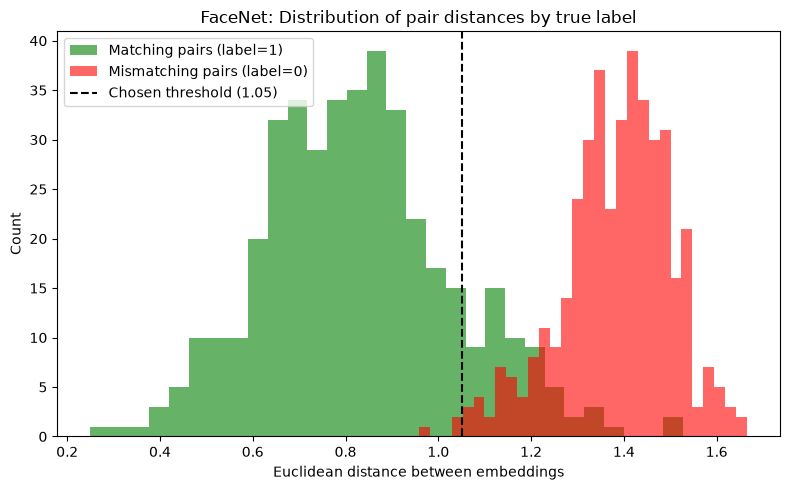

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(val_distances[val_labels_fn==1], bins=30, alpha=0.6, label='Matching pairs (label=1)', color='green')
plt.hist(val_distances[val_labels_fn==0], bins=30, alpha=0.6, label='Mismatching pairs (label=0)', color='red')
plt.axvline(1.05, color='black', linestyle='--', label='Chosen threshold (1.05)')
plt.xlabel('Euclidean distance between embeddings')
plt.ylabel('Count')
plt.title('FaceNet: Distribution of pair distances by true label')
plt.legend()
plt.tight_layout()
plt.savefig('facenet_distance_distribution.png', dpi=150)
plt.show()

**FAR/FRR vs. threshold curve (FaceNet)**

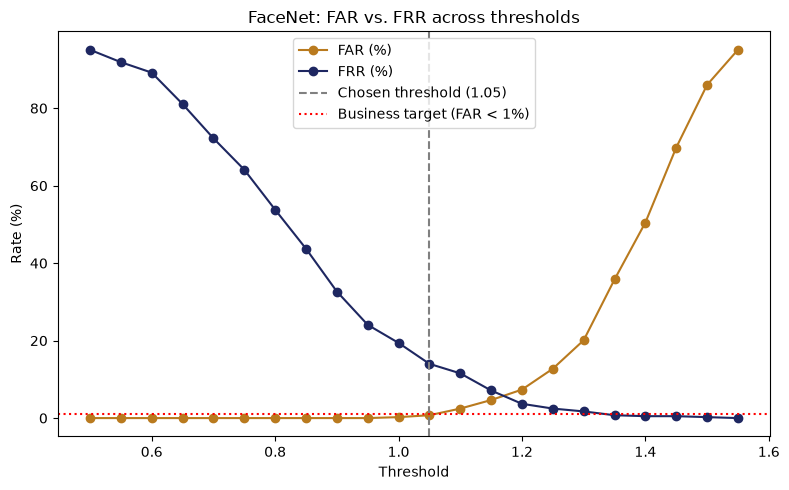

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(results_fn_df['threshold'], results_fn_df['FAR']*100, marker='o', label='FAR (%)', color='#B97A1E')
plt.plot(results_fn_df['threshold'], results_fn_df['FRR']*100, marker='o', label='FRR (%)', color='#1E2761')
plt.axvline(1.05, color='gray', linestyle='--', label='Chosen threshold (1.05)')
plt.axhline(1, color='red', linestyle=':', label='Business target (FAR < 1%)')
plt.xlabel('Threshold')
plt.ylabel('Rate (%)')
plt.title('FaceNet: FAR vs. FRR across thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('facenet_far_frr_curve.png', dpi=150)
plt.show()

**Side-by-side model comparison --final test set numbers -**

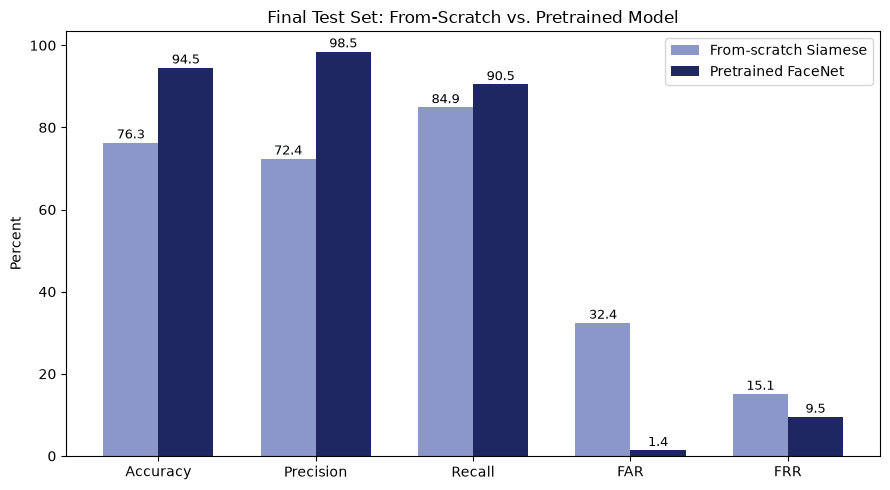

In [34]:
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'FAR', 'FRR']
siamese_scores = [76.3, 72.4, 84.9, 32.4, 15.1]
facenet_scores = [94.55, 98.48, 90.5, 1.4, 9.5]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, siamese_scores, width, label='From-scratch Siamese', color='#8C97C9')
bars2 = ax.bar(x + width/2, facenet_scores, width, label='Pretrained FaceNet', color='#1E2761')

ax.set_ylabel('Percent')
ax.set_title('Final Test Set: From-Scratch vs. Pretrained Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

**Images-per-identity skew **

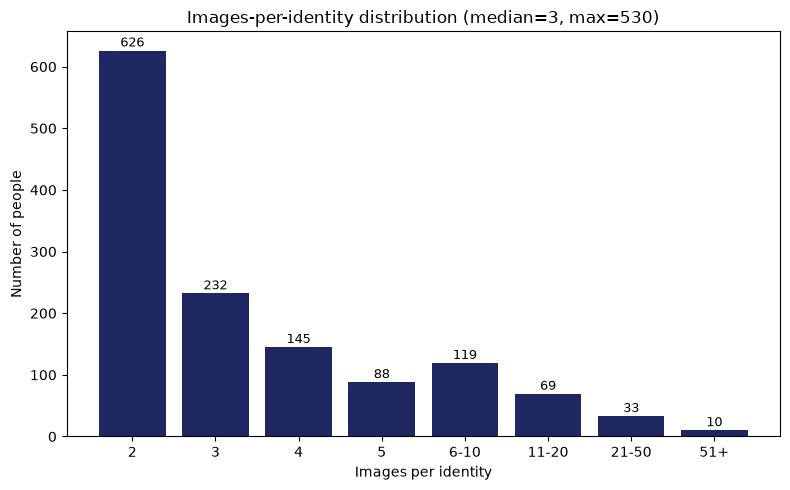

In [35]:
counts_series = pd.Series(image_counts)
bins = [2, 3, 4, 5, 6, 11, 21, 51, 531]
labels = ['2', '3', '4', '5', '6-10', '11-20', '21-50', '51+']
binned = pd.cut(counts_series, bins=bins, labels=labels, right=False, include_lowest=True)
bin_counts = binned.value_counts().reindex(labels)

plt.figure(figsize=(8, 5))
bars = plt.bar(bin_counts.index, bin_counts.values, color='#1E2761')
plt.xlabel('Images per identity')
plt.ylabel('Number of people')
plt.title(f'Images-per-identity distribution (median={int(counts_series.median())}, max={int(counts_series.max())})')
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('images_per_identity_skew.png', dpi=150)
plt.show()

**Train/test identity overlap**

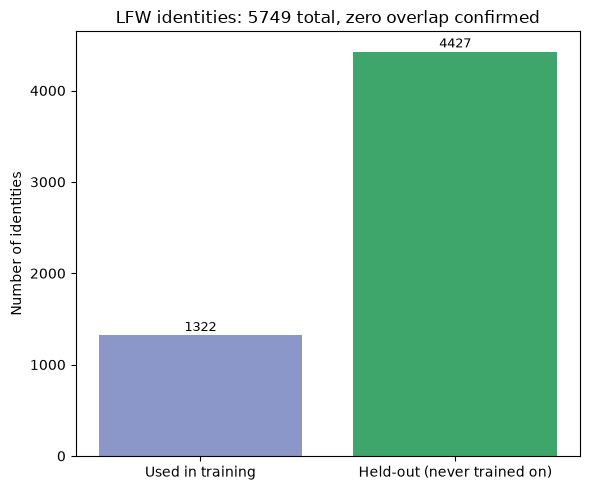

In [36]:
overlap_data = {
    'Used in training': len(train_identities),
    'Held-out (never trained on)': len(held_out_identities),
}

plt.figure(figsize=(6, 5))
colors = ['#8C97C9', '#3FA66B']
bars = plt.bar(overlap_data.keys(), overlap_data.values(), color=colors)
plt.ylabel('Number of identities')
plt.title(f'LFW identities: {len(all_test_identities)} total, zero overlap confirmed')
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('train_test_overlap.png', dpi=150)
plt.show()